# 2. PCA, the two generative models, and how well they work

Two ways to turn 500 simulated devices into an unlimited supply of realistic ones:

**Method A — covariance (`GaussianModel`).** Fit a multivariate normal to the
empirical mean and full covariance matrix. Every pairwise correlation is kept;
the model stores `p(p+1)/2` numbers.

**Method B — dominant PCA (`PCAModel`).** Standardize, keep only the `k` leading
principal components ("disorder modes"), sample independent Gaussians along them,
map back. Sub-dominant modes are set to zero, so the generated cloud lives on a
`k`-dimensional subspace. The model stores `k·p` numbers and each mode is a named
physical distortion of the device.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # so `import chargetwin` works from notebooks/

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import chargetwin as ct

In [2]:
PARAMS = ct.PAPER_PARAMETERS
DATASET = "rho5e10"
N_SAMPLES = 500
SEED = 0

raw = ct.load_dataset(DATASET, PARAMS)
raw.shape

(500, 7)

## The PCA: how many modes do you actually need?

Nearly 90% of the device-to-device variance sits in just three modes. The rest
falls into the noise floor you would expect for a finite sample of this size
(the Marchenko–Pastur region, in the paper's language).

Text(0.5, 1.0, 'rho5e10: top 3 modes = 88.3% of variance')

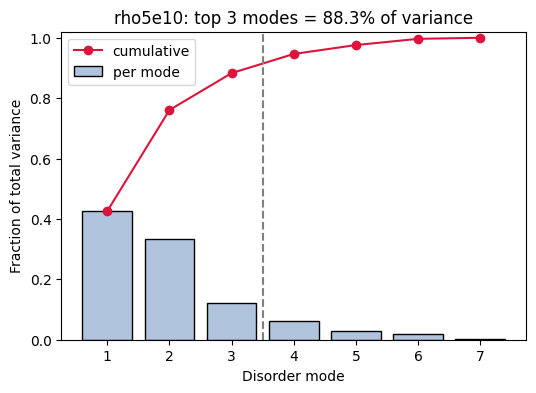

In [3]:
pca_full = ct.PCAModel.fit(raw, n_components=3)

fig, ax = plt.subplots(figsize=(6, 4))
ct.plot_explained_variance(pca_full, ax=ax)
ax.set_title(f"{DATASET}: top 3 modes = {pca_full.explained_variance_ratio[:3].sum():.1%} of variance")

### What the three dominant modes do

Read each column of the heat map as one physical way the charge disorder deforms
the double dot:

- **Mode 1 — symmetric squeeze/stretch.** `d` up, `log2tc` down, `Lxavg` down,
  `Favg` up, all together. An excess of trapped charge *between* the dots pushes
  them apart and collapses the tunnel coupling. The single largest source of
  device-to-device variability.
- **Mode 2 — asymmetric tilt.** `eps` and `dF` move together: the double well
  tilts, detuning the qubit. Caused by charge sitting closer to one dot.
- **Mode 3 — common vertical shift.** Almost pure `Favg`: the potential of both
  dots shifts relative to the barrier. Matters for valley splitting.

Text(0.5, 1.0, 'Disorder modes')

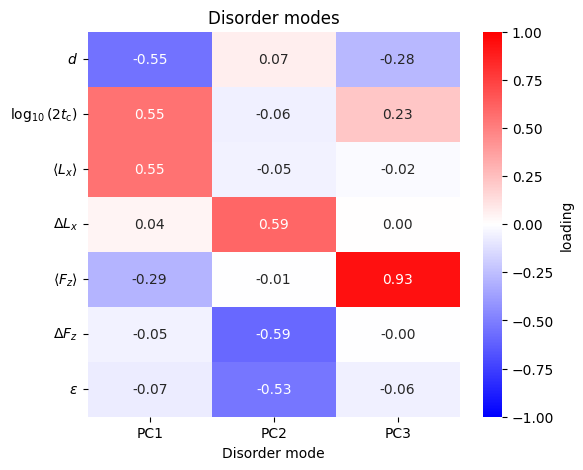

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ct.plot_mode_loadings(pca_full, n_modes=3, ax=ax)
ax.set_title("Disorder modes")

## Fit both models

In [5]:
gauss = ct.GaussianModel.fit(raw)                 # A
pca = ct.PCAModel.fit(raw, n_components=3)        # B

samples = {
    "Covariance": gauss.sample(N_SAMPLES, seed=SEED),
    "PCA": pca.sample(N_SAMPLES, seed=SEED),
}
samples["PCA"].head()

,d,log2tc,Lxavg,dLx,Favg,dF,eps
0,89.438088,1.546093,20.806433,-0.034831,5.277998,0.001054,0.243898
1,90.002172,1.520752,20.819108,-0.315646,5.273063,0.010264,1.525027
2,81.994116,1.985287,21.692374,0.770366,5.239461,-0.025768,-3.255782
3,105.362689,0.724373,19.745879,-0.447258,5.282022,0.015231,2.474194
4,120.746138,-0.040547,18.902930,-0.223950,5.269200,0.008494,2.003396


## The comparison

Blue = the real COMSOL ensemble, red = method A, yellow = method B. Method A
tracks the raw cloud everywhere. Method B reproduces the dominant correlations
but collapses the residual scatter — visible as a thinner cloud in exactly those
pairs that lived in the discarded modes.

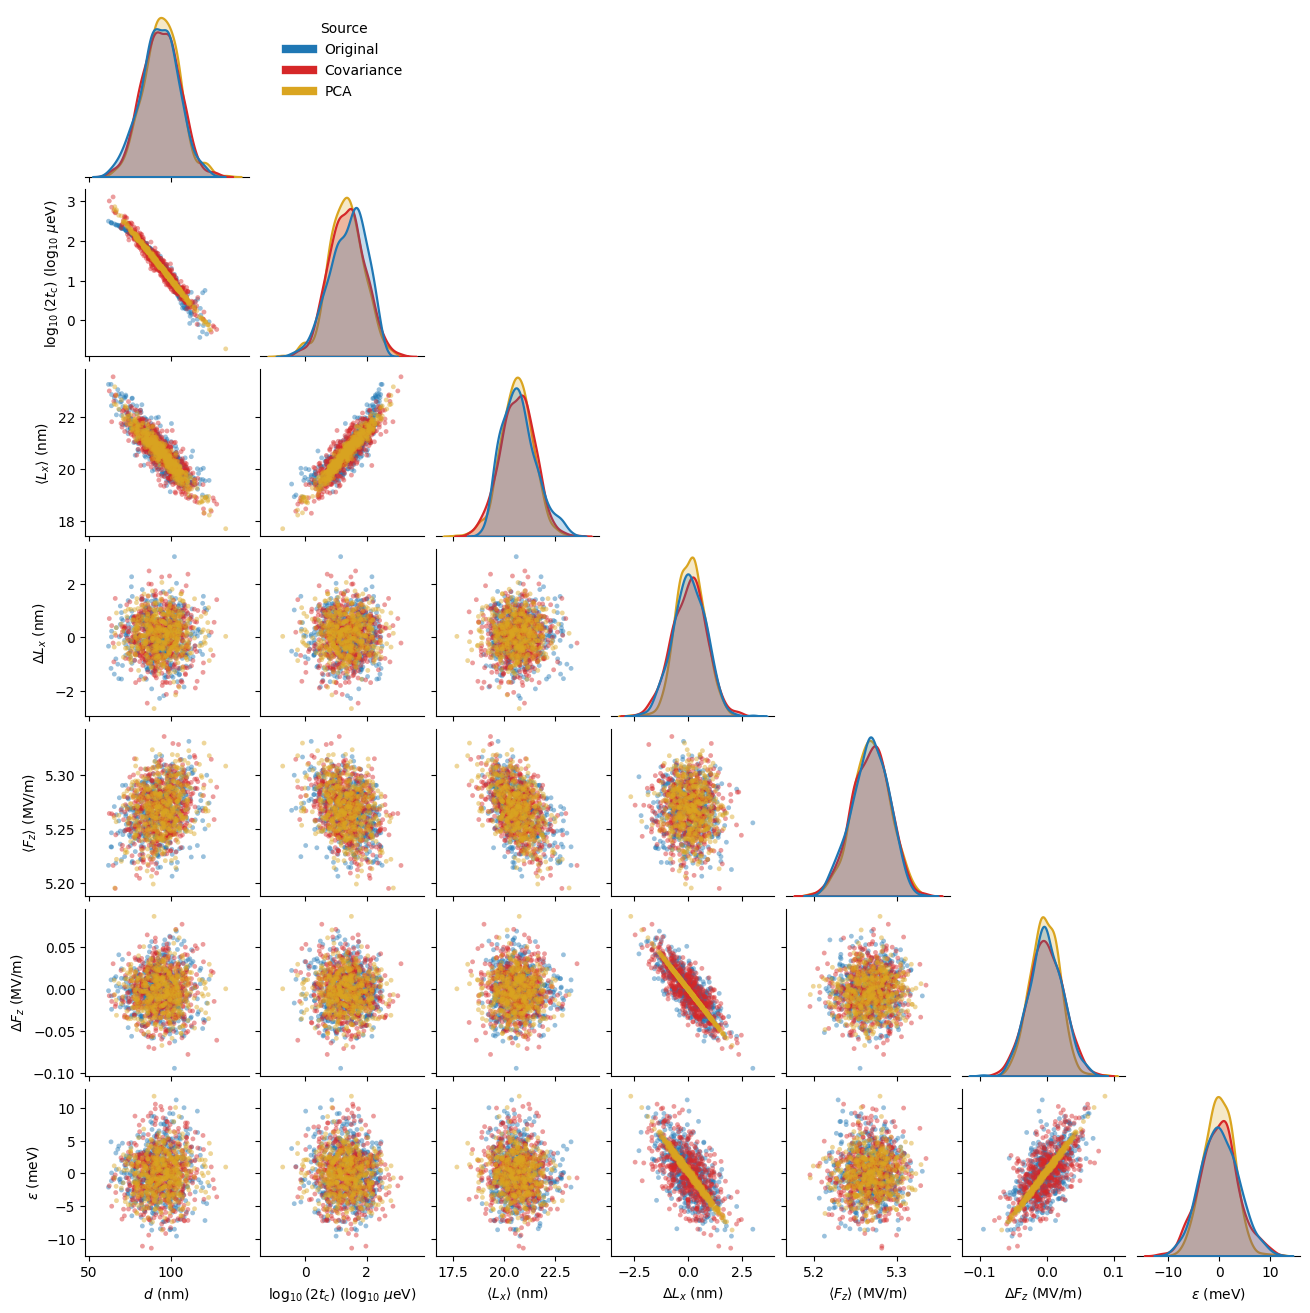

In [6]:
g = ct.pairplot_compare(raw, samples)

## Quantitatively

`ks` is the Kolmogorov–Smirnov distance between a generated marginal and the raw
one (0 = identical). `cov_rel_error` is the relative Frobenius error of the full
covariance matrix — this is where truncating the PCA costs you.

In [7]:
ct.marginal_summary(raw, samples).round(3)

,raw_mean,raw_std,Covariance_mean,Covariance_std,Covariance_ks,Covariance_ks_p,PCA_mean,PCA_std,PCA_ks,PCA_ks_p
parameter,,,,,,,,,,
d,92.753,11.231,93.542,11.106,0.040,0.819,94.175,10.785,0.070,0.173
log2tc,1.392,0.581,1.349,0.576,0.094,0.024,1.318,0.558,0.124,0.001
Lxavg,20.709,0.837,20.650,0.826,0.052,0.509,20.605,0.777,0.066,0.226
dLx,0.049,0.761,0.035,0.801,0.042,0.770,0.098,0.666,0.074,0.129
Favg,5.267,0.022,5.268,0.023,0.042,0.770,5.269,0.022,0.040,0.819
dF,-0.002,0.025,-0.002,0.026,0.040,0.819,-0.003,0.022,0.076,0.111
eps,0.036,3.683,-0.103,3.733,0.048,0.613,-0.147,2.932,0.094,0.024


In [8]:
ct.covariance_error(raw, samples).round(3)

,cov_rel_error,corr_rel_error
model,,
Covariance,0.028,0.050
PCA,0.087,0.221


### The log transform is doing real work

Fit the same Gaussian to the *linear* tunnel coupling and a few percent of the
generated devices come out with `t_c < 0`. There is no such thing as a negative
tunnel coupling.

negative t_c: 18.8% of samples (linear) vs 0.0% (log)


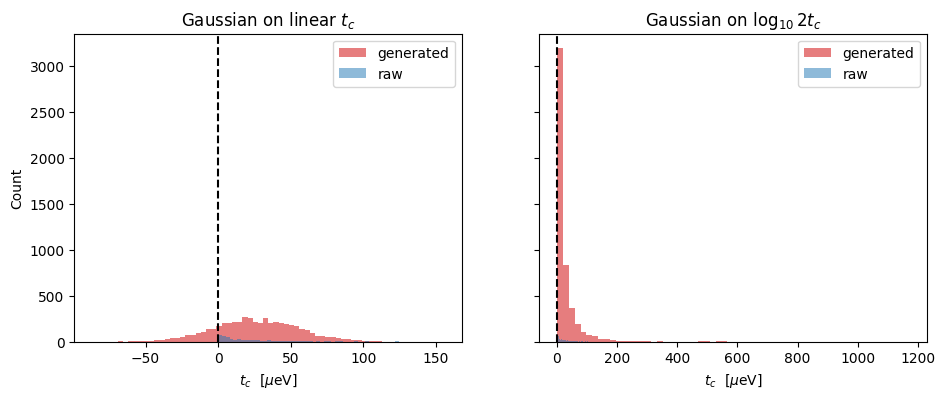

In [9]:
bad = ct.GaussianModel.fit(ct.load_dataset(DATASET, ["d", "tc"])).sample(5000, seed=SEED)
good = ct.add_tunnel_coupling(gauss.sample(5000, seed=SEED))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (df, title) in zip(axes, [(bad, "Gaussian on linear $t_c$"), (good, "Gaussian on $\\log_{10} 2t_c$")]):
    sns.histplot(df["tc"], ax=ax, bins=60, color="tab:red", edgecolor=None, alpha=0.6, label="generated")
    sns.histplot(ct.add_tunnel_coupling(raw)["tc"], ax=ax, bins=60, color="tab:blue",
                 edgecolor=None, alpha=0.5, stat="count", label="raw")
    ax.axvline(0, color="k", lw=1.5, ls="--")
    ax.set_xlabel(r"$t_c$  [$\mu$eV]")
    ax.set_title(title)
    ax.legend()

print(f"negative t_c: {(bad['tc'] < 0).mean():.1%} of samples (linear) "
      f"vs {(good['tc'] < 0).mean():.1%} (log)")

### The truncation trade-off, as a curve

More retained modes = smaller covariance error, at the cost of a bigger model.
Method A is the `k = p` limit.

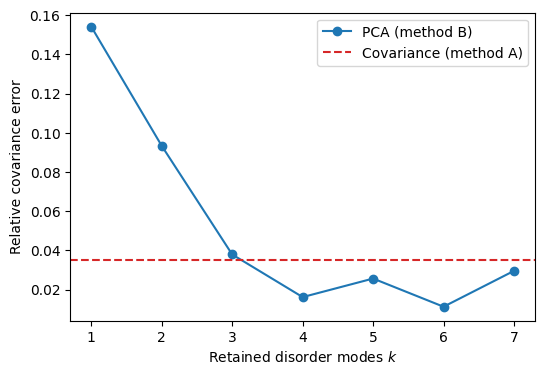

In [10]:
rows = []
for k in range(1, len(PARAMS) + 1):
    s = pca.with_n_components(k).sample(2000, seed=SEED)
    err = ct.covariance_error(raw, {"pca": s}).loc["pca", "cov_rel_error"]
    rows.append({"n_components": k, "cov_rel_error": err})
gauss_err = ct.covariance_error(raw, {"g": gauss.sample(2000, seed=SEED)}).loc["g", "cov_rel_error"]

curve = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(curve.n_components, curve.cov_rel_error, "o-", label="PCA (method B)")
ax.axhline(gauss_err, ls="--", c="tab:red", label="Covariance (method A)")
ax.set_xlabel("Retained disorder modes $k$")
ax.set_ylabel("Relative covariance error")
ax.legend()

## Save the fits

The `.npz` files hold only the fitted numbers — mean, covariance, modes — so
notebook 3 can generate devices without ever touching the raw ensemble.

In [11]:
gauss.save(ct.data.DATA_ROOT / "models" / f"{DATASET}_gaussian.npz")
pca.save(ct.data.DATA_ROOT / "models" / f"{DATASET}_pca3.npz")

PosixPath('/Users/krzywdaja/openspin-repos/ChargeTwin/data/models/rho5e10_pca3.npz')

Next: **`03_cooling_rounds.ipynb`** — the point of all this: many realizations of
the disorder, i.e. many cooldowns.